In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
from models import Autoencoder
from utils import get_device, crear_datasets_proporcionales, estandarizar_columnas_no_binarias, separar_columnas_binarias

df = pd.read_csv("../data/diabetes_012_health_indicators_BRFSS2015.csv")

# "Binarizamos" los datos, eliminando registros de pacientes con prediabetes
df = df[df["Diabetes_012"] != 1]
df["Diabetes_012"] = df["Diabetes_012"].replace(2, 1)

# Estandarizamos las columnas no binarias
df = estandarizar_columnas_no_binarias(df)
list_x_train, list_y_train, list_x_test, list_y_test, resumen_df = crear_datasets_proporcionales(df, "Diabetes_012")

device = get_device()

# Desempaquetamos los conjuntos train
x0_train, x1_train, x2_train, x3_train = list_x_train
y0_train, y1_train, y2_train, y3_train = list_y_train

# Desempaquetamos los conjuntos test
x0_test, x1_test, x2_test, x3_test = list_x_test
y0_test, y1_test, y2_test, y3_test = list_y_test

print(resumen_df)

Dispositivo usado: cuda (NVIDIA GeForce GTX 970)

   Proporción  Positivos  Negativos  Total  % Positivos  % Negativos
0        0.00          0      70692  70692          0.0        100.0
1        0.10       7069      63623  70692         10.0         90.0
2        0.25      17673      53019  70692         25.0         75.0
3        0.50      35346      35346  70692         50.0         50.0


Si se entrena un Autoencoder con un conjunto de datos $X$ (de entrenamiento) y luego se evalúa con un conjunto $T$ (de prueba) que sigue la misma distribución, se espera que:

$$
\lVert t'_1 - t_1 \rVert < \epsilon,
\qquad
t'_1 = \text{Decodificador}(\text{Codificador}(t_1)),
\qquad
t_1 \in T.
$$


In [3]:
idx_cols_binarias, idx_cols_no_binarias = separar_columnas_binarias(x0_train)
print(idx_cols_no_binarias)

[ 3 13 14 15 18 19 20]


In [12]:
from utils import evaluar_reconstruccion

modelo = Autoencoder.load(path="../models/autoencoder_2025-11-26T19.32_lr=0.0001_set=0.pth", device=device)
modelo.summary()

original = x0_test[y0_test==0]

original, reconstruccion, diferencias = evaluar_reconstruccion(modelo, original, device, idx_cols_binarias)

print(f"Media {np.mean(diferencias)}")

print("\nArray original:")
print(original[0])
print("\nArray reconstruido:")
print(reconstruccion[0])


Modelo cargado correctamente de '../models/autoencoder_2025-11-26T19.32_lr=0.0001_set=0.pth'
<Autoencoder: In 21 → 32 → 16 → [8] → 16 → 32 → 21 Out>
Media 0.695603235483221

Array original:
[ 0.          0.          0.         -0.50633874  1.          0.
  0.          1.          0.          0.          0.          0.
  1.          0.46588173 -0.42814476 -0.48414917  0.          0.
 -0.3311125   0.96059071 -2.45224647]

Array reconstruido:
[ 0.          0.          1.         -0.39950317  1.          0.
  0.          1.          0.          1.          0.          1.
  0.          0.46586648 -0.4275306  -0.38981792  0.          0.
 -0.3432783   0.92643464 -2.6420949 ]


El valor de $\epsilon$ (epsilon) se calcula de la siguiente manera:

$$
\epsilon =
\begin{cases}
\max(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 0, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 1, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) + 2\,\operatorname{std}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 2.
\end{cases}
$$


In [6]:
from utils import evaluar_reconstruccion, obtener_epsilon, obtener_matriz_confusion, obtener_metricas, graficar_matriz_confusion

X = x0_test
Y = y0_test

_, _, dif_norm = evaluar_reconstruccion(modelo, X[Y==0], device)
_, _, dif_anom = evaluar_reconstruccion(modelo, X[Y==1], device)

epsilon = obtener_epsilon(dif_norm, tipo_epsilon=1)

Luego las métricas se obtienen como:

$$
\begin{array}{rcl rcl}
\text{Accuracy} & = &
\dfrac{\text{TP} + \text{TN}}
      {\text{TP} + \text{FP} + \text{TN} + \text{FN}}
&
\text{Precision} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FP}}
\\[14pt]

\text{Recall} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FN}}
&
\text{Specificity} & = &
\dfrac{\text{TN}}
      {\text{TN} + \text{FP}}
\\[14pt]

\text{Balanced Accuracy} & = &
\dfrac{\dfrac{\text{TP}}{\text{TP}+\text{FN}} + \dfrac{\text{TN}}{\text{TN}+\text{FP}}}{2}
&
\text{F1\_Score} & = &
\dfrac{2\,\text{TP}}
      {2\,\text{TP} + \text{FP} + \text{FN}}
\end{array}
$$


En este caso veo más interesante analizar la métrica "precision" (creo que más importante) y "recall".

{'accuracy': 0.5362, 'precision': 0.2638, 'recall': 0.7484, 'specificity': 0.4838, 'balanced_accuracy': 0.6161, 'f1_score': 0.3901}


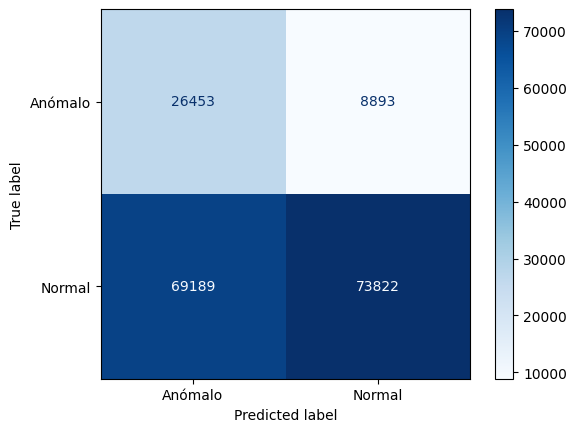

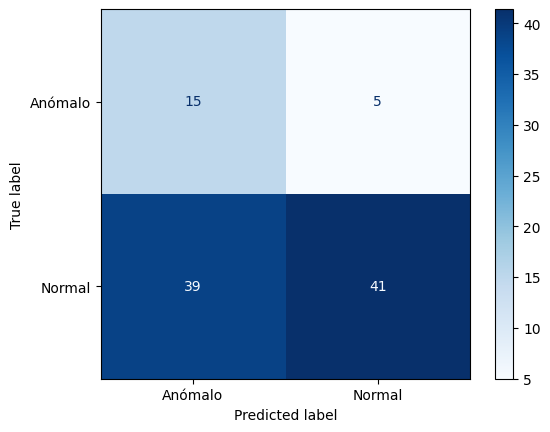

In [8]:
TP, FN, TN, FP = obtener_matriz_confusion(dif_norm, dif_anom, epsilon)
metricas = obtener_metricas(TP, FN, TN, FP)
print(metricas)
graficar_matriz_confusion(TP, FN, TN, FP)